In [1]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

In [2]:
def generate_sequence(length =100):
  return [i for i in range(length)]

In [3]:
# Create Input and Target Sequnece
sequence_length = 13
sequences = generate_sequence(length=sequence_length+1)

In [4]:
# Create input and Target Data
x = np.array([sequences[i:i+sequence_length] for i in range(len(sequences)-sequence_length)])
y = np.array(sequences[sequence_length:])

In [5]:
x = x.reshape((x.shape[0], x.shape[1],1))

In [6]:
x.ndim

3

In [7]:
model = Sequential()
model.add(SimpleRNN(50, activation='relu', input_shape=(sequence_length,1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

c:\python310\lib\site-packages\keras\src\layers\rnn\rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


In [8]:
print(x.shape)
print(y.shape)

(1, 13, 1)
(1,)


In [9]:
model.fit(x,y, epochs=100, verbose=1)

Epoch 1/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 2s 2s/step - loss: 126.2616
Epoch 2/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 84ms/step - loss: 105.8369
Epoch 3/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 84.9759
Epoch 4/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 80ms/step - loss: 66.1069
Epoch 5/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 82ms/step - loss: 49.1114
Epoch 6/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 83ms/step - loss: 34.1681
Epoch 7/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 77ms/step - loss: 21.5991
Epoch 8/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 72ms/step - loss: 11.6609
Epoch 9/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 73ms/step - loss: 4.6624
Epoch 10/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 0.7728
Epoch 11/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 70ms/step - loss: 0.1500
Epoch 12/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 74ms/step - loss: 2.4087
Epoch 13/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 68ms/step - loss: 5.7469
Epoch 14/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 317ms/step - loss: 8.6723
Epoch 15/100
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 76ms/step - loss: 10.3533
Epoch 16/

In [10]:
test_sequence = generate_sequence(length=sequence_length)
test_input = np.array(test_sequence).reshape((1, sequence_length, 1))


In [11]:
predicted_number = model.predict(test_input, verbose=1)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 244ms/step


In [12]:
print("Input Sequnece: " , test_sequence)
print("Predicted Next Number : ", predicted_number[0,0])

Input Sequnece:  [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Predicted Next Number :  13.033757


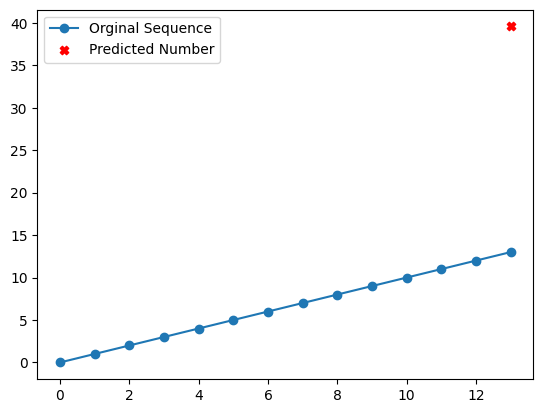

In [15]:
plt.plot(sequences, marker='o', label="Orginal Sequence")
plt.scatter(sequence_length, predicted_number, color="red", marker='X',label="Predicted Number")
plt.legend()
plt.show()

Input Sequence: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Corresponding Multiples of 3: [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36]
Predicted Next Multiple of 3: 38.562046


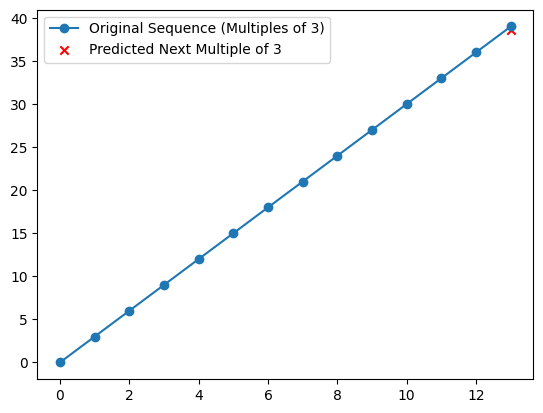

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

def generate_sequence(length=100):
    return [i for i in range(length)]

def create_data_for_multiples_of_3(sequence_length=13):
    sequences = generate_sequence(length=sequence_length + 1)
    X = np.array([sequences[i:i+sequence_length] for i in range(len(sequences)-sequence_length)])
    y = np.array([i * 3 for i in sequences[sequence_length:]])
    X = X.reshape((X.shape[0], X.shape[1], 1))
    return X, y

sequence_length = 13
X, y = create_data_for_multiples_of_3(sequence_length)

model = Sequential()
model.add(SimpleRNN(50, activation='relu', input_shape=(sequence_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(X, y, epochs=100, verbose=0)

test_sequence = generate_sequence(length=sequence_length)
test_input = np.array(test_sequence).reshape((1, sequence_length, 1))

predicted_number = model.predict(test_input, verbose=0)

print("Input Sequence:", test_sequence)
print("Corresponding Multiples of 3:", [i * 3 for i in test_sequence])
print("Predicted Next Multiple of 3:", predicted_number[0, 0])

plt.plot([i * 3 for i in sequences], marker='o', label='Original Sequence (Multiples of 3)')
plt.scatter(sequence_length, predicted_number, color='red', marker='x', label='Predicted Next Multiple of 3')
plt.legend()
plt.show()


Input Sequence: [0, 1, 2, 3, 4, 5, 6, 7, 8, 9, 10, 11, 12]
Corresponding Multiples of 3: [0, 3, 6, 9, 12, 15, 18, 21, 24, 27, 30, 33, 36]
Predicted Next Multiple of 3: 39.561348


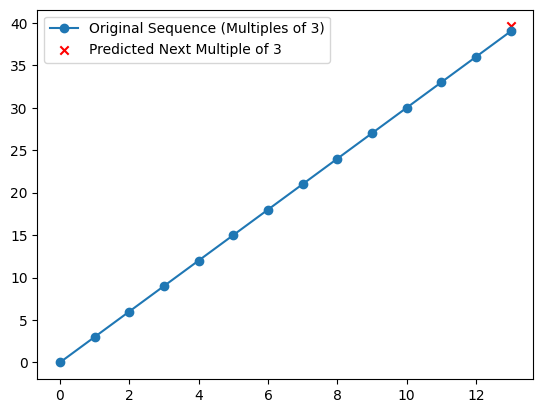

In [14]:
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import SimpleRNN, Dense

def generate_sequence(length=100):
    return [i for i in range(length)]

def create_data_for_multiples_of_3(sequence_length=13):
    sequences = generate_sequence(length=sequence_length + 1)
    X = np.array([sequences[i:i+sequence_length] for i in range(len(sequences)-sequence_length)])
    y = np.array([i * 3 for i in sequences[sequence_length:]])
    X = X.reshape((X.shape[0], X.shape[1], 1))
    return X, y

sequence_length = 13
X, y = create_data_for_multiples_of_3(sequence_length)

model = Sequential()
model.add(SimpleRNN(50, activation='relu', input_shape=(sequence_length, 1)))
model.add(Dense(1))
model.compile(optimizer='adam', loss='mean_squared_error')

model.fit(X, y, epochs=100, verbose=0)

test_sequence = generate_sequence(length=sequence_length)
test_input = np.array(test_sequence).reshape((1, sequence_length, 1))

predicted_number = model.predict(test_input, verbose=0)

print("Input Sequence:", test_sequence)
print("Corresponding Multiples of 3:", [i * 3 for i in test_sequence])
print("Predicted Next Multiple of 3:", predicted_number[0, 0])

plt.plot([i * 3 for i in sequences], marker='o', label='Original Sequence (Multiples of 3)')
plt.scatter(sequence_length, predicted_number, color='red', marker='x', label='Predicted Next Multiple of 3')
plt.legend()
plt.show()


In [17]:
import numpy as np
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense
from tensorflow.keras.datasets import mnist
from tensorflow.keras.utils import to_categorical


# Loading The Mnsit Dataset And Splitting Them in X_train , X-test . y_train And Y_test
(x_train, y_train), (x_test, y_test) = mnist.load_data()


# Normalise The Input Data By DIviding By 255
x_train = x_train.astype('float32') / 255.0
x_test = x_test.astype('float32') / 255.0

# One Hot ENcode The Labels
y_train = to_categorical(y_train, 10)
y_test = to_categorical(y_test, 10)


# Reshape The Input Data To 3D for LSTM Input
x_train = x_train.reshape(x_train.shape[0], 28, 28)
x_test = x_test.reshape(x_test.shape[0], 28, 28)


# Buiding The LSTM  Model
model = Sequential()
model.add(LSTM(50, input_shape=(28, 28)))
model.add(Dense(10, activation='softmax'))

# Compilation Of The Model
model.compile(loss='categorical_crossentropy', optimizer='adam', metrics=['accuracy'])

# Train The Model , Here validation_split is Testing Size
model.fit(x_train, y_train, epochs=10, batch_size=64, validation_split=0.2)

# Evaluate The Model On Test Data
loss, accuracy = model.evaluate(x_test, y_test)
print(f'Test Loss: {loss}, Test Accuracy: {accuracy}')


Epoch 1/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 11s 12ms/step - accuracy: 0.7745 - loss: 0.7020 - val_accuracy: 0.9200 - val_loss: 0.2641
Epoch 2/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9351 - loss: 0.2197 - val_accuracy: 0.9465 - val_loss: 0.1842
Epoch 3/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 9ms/step - accuracy: 0.9556 - loss: 0.1515 - val_accuracy: 0.9613 - val_loss: 0.1333
Epoch 4/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 11ms/step - accuracy: 0.9644 - loss: 0.1205 - val_accuracy: 0.9688 - val_loss: 0.1082
Epoch 5/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9703 - loss: 0.1004 - val_accuracy: 0.9722 - val_loss: 0.0931
Epoch 6/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 8s 10ms/step - accuracy: 0.9737 - loss: 0.0861 - val_accuracy: 0.9707 - val_loss: 0.0990
Epoch 7/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 9s 11ms/step - accuracy: 0.9766 - loss: 0.0762 - val_accuracy: 0.9727 - val_loss: 0.0898
Epoch 8/10
750/750 ━━━━━━━━━━━━━━━━━━━━ 7s 10ms/step - accuracy: 0.9796 - loss: 0.0669 - val_accur